In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import pandas as pd
import seaborn as sns
import shap

from cdc_ml.config import (
    CUSTOMER_CLASS_PROCESSED,
    FEATURE_ABLATIONS_RESULTS,
    POLLS_PROCESSED,
    PREFERENCE_PROCESSED,
    REPORTS_FIGURE,
)

from cdc_ml.features.build_features import (
    build_features,
    get_whale_users,
)

from cdc_ml.modeling.config import (
    CHOSEN_FEATURES,
    FEATS_ABL_LIST,
)

from cdc_ml.modeling.data import (
    make_holdout_split,
)

from cdc_ml.modeling.cv import(

    run_cv
)

from cdc_ml.modeling.evaluation import (
    adversarial_validation,
    compare_feature_sets,
    paired_t,
    per_customer_at_budget,
    pr_auc_ci_by_user,
)

from cdc_ml.modeling.tune import randSearch
from cdc_ml.modeling.train import train

from cdc_ml.plots import (
    bootstrapped_gain_curve,
    plot_calibration_by_volume,
)



c:\Users\zhiju\Desktop\cdc_ml\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-06-08 17:09:20.651 | INFO     | cdc_ml.config:<module>:12 - PROJ_ROOT path is: C:\Users\zhiju\Desktop\cdc_ml


In [3]:
df = pd.read_parquet(POLLS_PROCESSED)
df_pref = pd.read_parquet(PREFERENCE_PROCESSED)
df_class = pd.read_parquet(CUSTOMER_CLASS_PROCESSED)

In [4]:
df_pref.loc[(df_pref["id"]==44)]

,id,username,day_of_week,pref_start,pref_end,date,t_0830,t_1020,t_1245,t_1435,t_1625,t_1850,t_2040
1106,44,kim,4,2025-12-05 00:00:00+08:00,2025-12-05 23:00:00+08:00,2025-12-05 23:00:00+08:00,1,1,1,1,0,0,0
1107,44,kim,4,2025-12-12 00:00:00+08:00,2025-12-12 23:00:00+08:00,2025-12-12 23:00:00+08:00,1,1,1,1,0,0,0
1108,44,kim,4,2025-12-19 00:00:00+08:00,2025-12-19 23:00:00+08:00,2025-12-19 23:00:00+08:00,1,1,1,1,0,0,0
1109,44,kim,4,2025-12-26 00:00:00+08:00,2025-12-26 23:00:00+08:00,2025-12-26 23:00:00+08:00,1,1,1,1,0,0,0
1110,44,kim,0,2025-12-29 00:00:00+08:00,2025-12-30 23:00:00+08:00,2025-12-29 23:00:00+08:00,1,1,1,1,0,0,0
1111,44,kim,1,2025-12-29 00:00:00+08:00,2025-12-30 23:00:00+08:00,2025-12-30 23:00:00+08:00,1,1,1,1,0,0,0
1112,44,kim,4,2026-01-02 00:00:00+08:00,2026-01-02 23:00:00+08:00,2026-01-02 23:00:00+08:00,1,1,1,1,0,0,0
1113,44,kim,4,2026-01-09 00:00:00+08:00,2026-01-09 23:00:00+08:00,2026-01-09 23:00:00+08:00,1,1,1,1,0,0,0
1114,44,kim,4,2026-01-16 00:00:00+08:00,2026-01-16 23:00:00+08:00,2026-01-16 23:00:00+08:00,1,1,1,1,0,0,0
1115,44,kim,4,2026-01-23 00:00:00+08:00,2026-01-23 23:00:00+08:00,2026-01-23 23:00:00+08:00,1,1,1,1,0,0,0


In [5]:
df = build_features(df,df_pref,df_class)

In [6]:
df.info()

<class 'pandas.DataFrame'>
Index: 29612 entries, 1126 to 29123
Data columns (total 29 columns):
 #   Column                Non-Null Count  Dtype                         
---  ------                --------------  -----                         
 0   id                    29612 non-null  int64                         
 1   username              29612 non-null  str                           
 2   cycle_start           29612 non-null  datetime64[us, Asia/Singapore]
 3   cycle_end             29612 non-null  datetime64[us, Asia/Singapore]
 4   polling_at            29612 non-null  datetime64[us, Asia/Singapore]
 5   has_booking           29612 non-null  bool                          
 6   cycle_start_month     29612 non-null  int32                         
 7   cycle_start_day       29612 non-null  int32                         
 8   cycle_start_dow       29612 non-null  int32                         
 9   cycle_start_hour      29612 non-null  int32                         
 10  polling_mon

In [7]:
df.head()

,id,username,cycle_start,cycle_end,polling_at,has_booking,cycle_start_month,cycle_start_day,cycle_start_dow,cycle_start_hour,...,pref_unique_timeslot,pref_dow_count_0,pref_dow_count_1,pref_dow_count_2,pref_dow_count_3,pref_dow_count_4,pref_dow_count_5,pref_dow_count_6,date,pref_valid
1126,6,matt,2025-08-12 01:21:00+08:00,2025-09-23 23:52:00+08:00,2025-08-12 06:00:00+08:00,False,8,12,1,1,...,5,2,2,2,2,1,3,3,"[2025-08-18 23:00:00+08:00, 2025-08-19 23:00:0...",57
1218,6,matt,2025-08-12 01:21:00+08:00,2025-09-23 23:52:00+08:00,2025-08-16 02:00:00+08:00,False,8,12,1,1,...,5,2,2,2,2,1,3,3,"[2025-08-18 23:00:00+08:00, 2025-08-19 23:00:0...",57
1217,6,matt,2025-08-12 01:21:00+08:00,2025-09-23 23:52:00+08:00,2025-08-16 01:00:00+08:00,False,8,12,1,1,...,5,2,2,2,2,1,3,3,"[2025-08-18 23:00:00+08:00, 2025-08-19 23:00:0...",57
1216,6,matt,2025-08-12 01:21:00+08:00,2025-09-23 23:52:00+08:00,2025-08-16 00:00:00+08:00,False,8,12,1,1,...,5,2,2,2,2,1,3,3,"[2025-08-18 23:00:00+08:00, 2025-08-19 23:00:0...",57
1215,6,matt,2025-08-12 01:21:00+08:00,2025-09-23 23:52:00+08:00,2025-08-15 23:00:00+08:00,False,8,12,1,1,...,5,2,2,2,2,1,3,3,"[2025-08-18 23:00:00+08:00, 2025-08-19 23:00:0...",57


In [8]:
df["is_one_team"].describe()

count    29612.000000
mean         0.300824
std          0.458624
min          0.000000
25%          0.000000
50%          0.000000
75%          1.000000
max          1.000000
Name: is_one_team, dtype: float64

In [9]:
df_train, df_test = make_holdout_split(df)


Train share -> 0.7927191679049034
Test share -> 0.2072808320950966
Baseline positive rate -> 0.013170336350128327
Train positive rate -> 0.013759904575274772
Test positive rate -> 0.010915607689801238


In [10]:
df_train.head(1)

,id,username,cycle_start,cycle_end,polling_at,has_booking,cycle_start_month,cycle_start_day,cycle_start_dow,cycle_start_hour,...,pref_unique_timeslot,pref_dow_count_0,pref_dow_count_1,pref_dow_count_2,pref_dow_count_3,pref_dow_count_4,pref_dow_count_5,pref_dow_count_6,date,pref_valid
1126,6,matt,2025-08-12 01:21:00+08:00,2025-09-23 23:52:00+08:00,2025-08-12 06:00:00+08:00,False,8,12,1,1,...,5,2,2,2,2,1,3,3,"[2025-08-18 23:00:00+08:00, 2025-08-19 23:00:0...",57


In [11]:
for test_type,test_list in FEATS_ABL_LIST.items():
    for feature_name,features_list in test_list.items():
        _ = run_cv(df_train,test_type+"_"+feature_name,features_list,m_depth=4,min_child=15,reg_lamb=15)


fold 0: train n= 18818 val n=  4656   train_pos=0.014  val_pos=0.014
  const  brier=0.0140  pr=0.0142
  marg_dow  brier=0.0140  pr=0.0153
  marg_hour brier=0.0138  pr=0.0344
  add       brier=0.0138  pr=0.0402
  joint     brier=0.0138  pr=0.0400
  rf        brier=0.0137  pr=0.0396
  xgb (val) brier=0.0138  pr=0.0403
  xgb (tr)  brier=0.0133  pr=0.0370

fold 1: train n= 19062 val n=  4412   train_pos=0.012  val_pos=0.023
  const  brier=0.0227  pr=0.0231
  marg_dow  brier=0.0227  pr=0.0301
  marg_hour brier=0.0225  pr=0.0447
  add       brier=0.0224  pr=0.0510
  joint     brier=0.0226  pr=0.0422
  rf        brier=0.0224  pr=0.0498
  xgb (val) brier=0.0224  pr=0.0511
  xgb (tr)  brier=0.0113  pr=0.0352

fold 2: train n= 18837 val n=  4637   train_pos=0.014  val_pos=0.014
  const  brier=0.0140  pr=0.0142
  marg_dow  brier=0.0140  pr=0.0181
  marg_hour brier=0.0139  pr=0.0375
  add       brier=0.0138  pr=0.0463
  joint     brier=0.0139  pr=0.0378
  rf        brier=0.0139  pr=0.0365
  xgb (v

In [12]:
xgb_records = pd.read_json(FEATURE_ABLATIONS_RESULTS,lines=True)
model_metrics = compare_feature_sets(target_run="full_loo_loo")

In [13]:
model_metrics

,run_at,run_id,feature_id,split,group,n_folds,seed,features,n,base_rate,...,imp_polling_month,imp_polling_day,imp_pref_coverage,imp_pref_unique_day,imp_pref_dow_count_3,imp_pref_dow_count_0,imp_pref_dow_count_2,imp_pref_dow_count_6,imp_pref_dow_count_1,imp_pref_dow_count_5


In [14]:
X_train, y_train = df_train[CHOSEN_FEATURES],df_train["has_booking"].to_numpy()

X_test, y_test = df_test[CHOSEN_FEATURES], df_test["has_booking"].to_numpy()

In [15]:
randSearch(X_train,y_train,df_train["username"])

Fitting 5 folds for each of 50 candidates, totalling 250 fits
0.0751709903575516 {'subsample': 0.9, 'reg_lambda': 20, 'n_estimators': 200, 'min_child_weight': 5, 'max_depth': 5, 'learning_rate': 0.1, 'gamma': 1.0, 'colsample_bytree': 0.8}
2026-06-08 17:11:34.844 | SUCCESS  | cdc_ml.modeling.tune:randSearch:28 - Saved best params to C:\Users\zhiju\Desktop\cdc_ml\models\best_params.json


In [16]:
model,oof_cal = train(df_train)

2026-06-08 17:11:35.281 | SUCCESS  | cdc_ml.modeling.train:train:64 - Saved model to C:\Users\zhiju\Desktop\cdc_ml\models\booking_model_v1.joblib


In [17]:
whales_pc,_ = get_whale_users()
whales_pt_mask_train = df_train["username"].isin(whales_pc).to_numpy()
non_whales_pt_mask_train = ~df_train["username"].isin(whales_pc).to_numpy()

whales_pt_mask_test = df_test["username"].isin(whales_pc).to_numpy()
non_whales_pt_mask_test = ~df_test["username"].isin(whales_pc).to_numpy()

In [18]:
p_cal = model.predict_proba(df_test)

whale_users = df_test.loc[whales_pt_mask_test,["username"]]
non_whales_users = df_test.loc[non_whales_pt_mask_test,["username"]]
print("ALL");        pr_auc_ci_by_user(y_test, p_cal, df_test["username"])
print("WHALES");     pr_auc_ci_by_user(y_test[whales_pt_mask_test],  p_cal[whales_pt_mask_test],  whale_users)
print("NON-WHALES"); pr_auc_ci_by_user(y_test[~whales_pt_mask_test], p_cal[~whales_pt_mask_test], non_whales_users)

ALL
users=7 rows=6138 positives=67 base=0.0109
PR-AUC=0.0285 (2.61x)  95% CI=[0.0166, 0.0524] ([1.52x, 4.80x])

WHALES
users=1 rows=3816 positives=22 base=0.0058
PR-AUC=0.0149 (2.59x)  95% CI=[0.0149, 0.0149] ([2.59x, 2.59x])

NON-WHALES
users=6 rows=2322 positives=45 base=0.0194
PR-AUC=0.0361 (1.86x)  95% CI=[0.0235, 0.0632] ([1.21x, 3.26x])



([0.06316181662266923,
  0.04359715410526619,
  0.0650655958134846,
  0.042531017840420876,
  0.03644719819586693,
  0.046129428031013886,
  0.024520056152416092,
  0.051815729667813545,
  0.03203191142118673,
  0.036077290726132034,
  0.03253454677796895,
  0.0444543029148055,
  0.025998206344034783,
  0.0466095513446987,
  0.03875150758180141,
  0.04803209911201334,
  0.03043918204040961,
  0.033793823703248606,
  0.03178366063262112,
  0.0408716124112386,
  0.03571618466281215,
  0.05252126846319283,
  0.02733901970073902,
  0.05823251781576008,
  0.024721254029680992,
  0.0308664366318777,
  0.03487846316548723,
  0.03018301177182605,
  0.036276948365034395,
  0.03279189516033634,
  0.032524728251173585,
  0.03277478011512047,
  0.0308664366318777,
  0.02657638828087577,
  0.03192726926191082,
  0.03944481060217288,
  0.043224356651149244,
  0.04359715410526619,
  0.04154858354544195,
  0.037128781153104785,
  0.03128953957585205,
  0.04879461926087644,
  0.03666862407036668,
  0.0

In [19]:
clf = adversarial_validation(X_train[CHOSEN_FEATURES], X_test[CHOSEN_FEATURES])

adversarial AUC = 0.702   (0.5 = identical, ~0.65+ = medium, 0.8+ = strong)


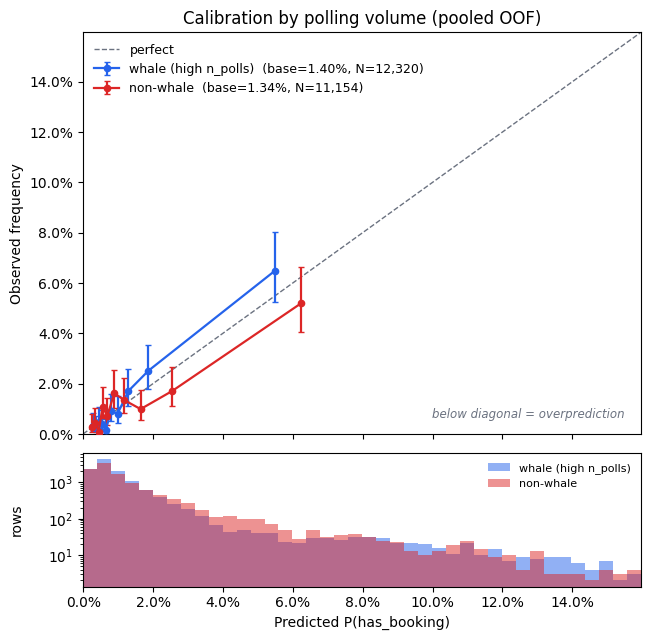

In [20]:
fig = plot_calibration_by_volume(oof_cal,y_train,whales_pt_mask_train);
fig.savefig(REPORTS_FIGURE/"oof_cali.png")

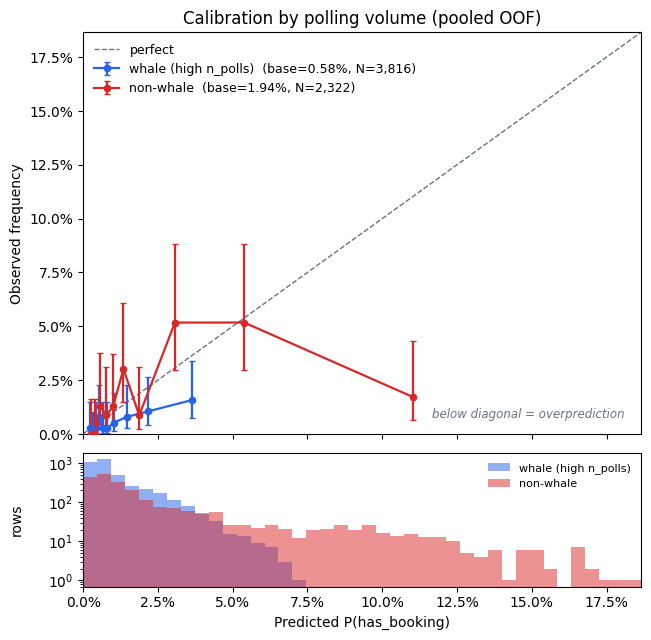

In [21]:
fig = plot_calibration_by_volume(
    p_cal,
    y_test,
    whales_pt_mask_test
)

fig.savefig(REPORTS_FIGURE/"test_cali.png")

 booking whales: median recall 82%, worst 73%  (n=2)
       the rest: median recall 100%, worst 57%  (n=5)


<Axes: xlabel='whale', ylabel='recall'>

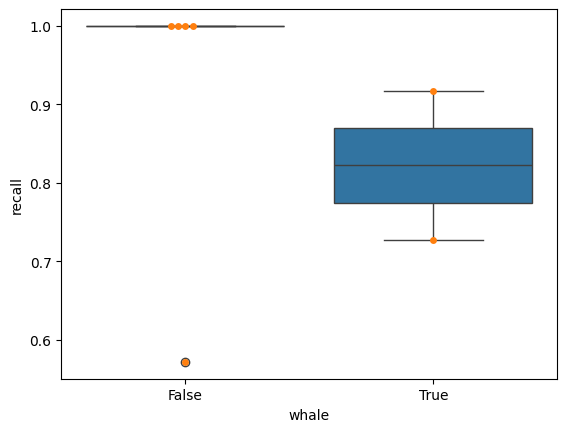

In [22]:
t = per_customer_at_budget(df_test, p_cal, budget=0.50)
for name, g in [("booking whales", t[t.whale]), ("the rest", t[~t.whale])]:
    print(f"{name:>15}: median recall {g.recall.median():.0%}, "
          f"worst {g.recall.min():.0%}  (n={len(g)})")
sns.boxplot(data=t,x="whale",y="recall")  # if you want the distribution, not just the summary
sns.swarmplot(data=t,x="whale",y="recall")  # if you want the distribution, not just the summary

 booking whales: median recall 91%, worst 57%  (n=4)
       the rest: median recall 91%, worst 0%  (n=26)


<Axes: xlabel='whale', ylabel='recall'>

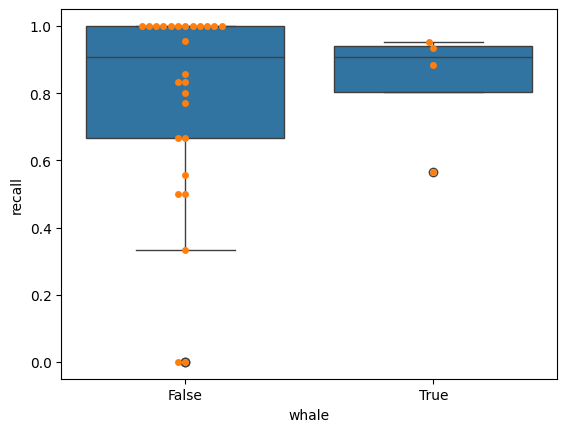

In [23]:

t = per_customer_at_budget(df_train, oof_cal, budget=0.50)
for name, g in [("booking whales", t[t.whale]), ("the rest", t[~t.whale])]:
    print(f"{name:>15}: median recall {g.recall.median():.0%}, "
          f"worst {g.recall.min():.0%}  (n={len(g)})")
sns.boxplot(data=t,x="whale",y="recall")  # if you want the distribution, not just the summary
sns.swarmplot(data=t,x="whale",y="recall")  # if you want the distribution, not just the summary

In [24]:
fig, res = bootstrapped_gain_curve(df_train, oof_cal)
fig.savefig(REPORTS_FIGURE/"bootstrapped_gain_curve_oof.png")
print(f"90% of bookings for {res['budget']*100:.0f}% of polls (95% CI {res['budget_ci'][0]*100:.0f}-{res['budget_ci'][2]*100:.0f}%)")

KeyError: 'grid'

90% of bookings for 49% of polls (95% CI 43-77%)


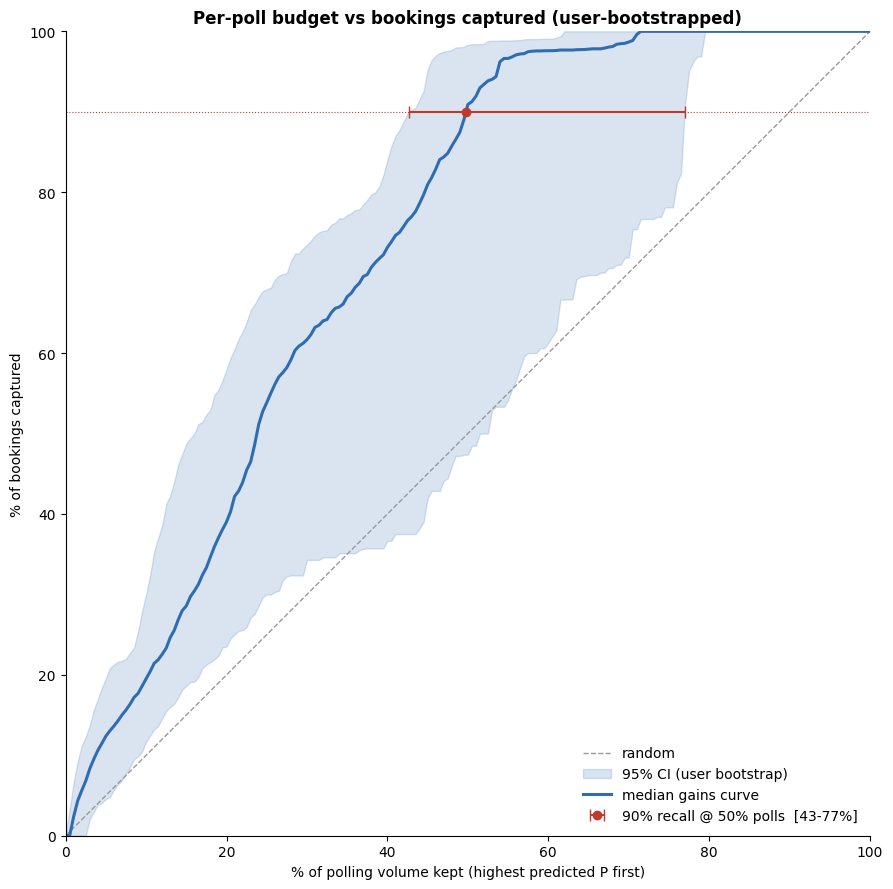

In [ ]:
fig, res = bootstrapped_gain_curve(df_test, p_cal)
fig.savefig(REPORTS_FIGURE/"bootstrapped_gain_curve_test.png")
print(f"90% of bookings for {res['budget']*100:.0f}% of polls (95% CI {res['budget_ci'][0]*100:.0f}-{res['budget_ci'][2]*100:.0f}%)")

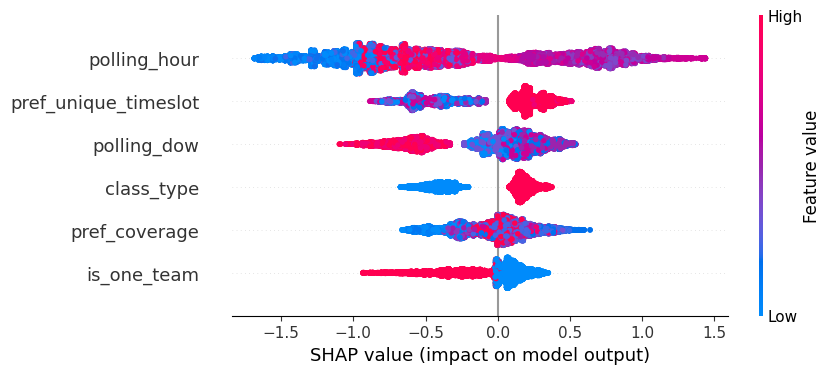

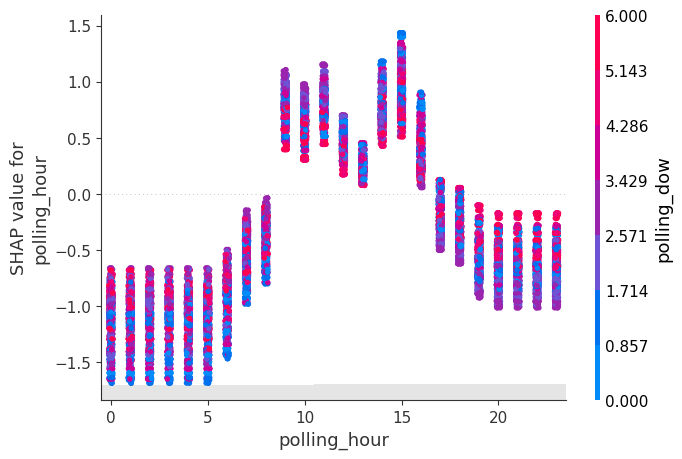

In [ ]:
explainer = shap.TreeExplainer(model.booster)   # raw margin = log-odds
sv = explainer(df_train[CHOSEN_FEATURES])                   # X_eval = held-out sample
shap.plots.beeswarm(sv)
shap.plots.scatter(sv[:, "polling_hour"], color=sv[:, "polling_dow"])
# older shap: shap.summary_plot(explainer.shap_values(X_eval), X_eval)